In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import scipy
import statsmodels.api as sm

In [2]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

In [3]:
chess_data = pd.read_csv("Chess Project data.csv")
chess_data

,Game,White,Black,White Elo,Black Elo,White RD,Black RD,WhiteIsComp,BlackIsComp,TimeControl,Date,Time,White Clock,Black Clock,ECO,PlyCount,Result,Result-Winner,Commentaries,Moves
0,"""zerowin"" vs ""GeidiPrime""",zerowin,GeidiPrime,2848,2464,0.0,0.0,Yes,Yes,900+0,2016.12.31,23:17:00,15:00.0,15:00.0,A30,72,1/2-1/2,Draw,Game drawn by mutual agreement,1. c4 c5 2. Nf3 e6 3. g3 b6 4. Bg2 Bb7 5. O-O ...
1,"""GeidiPrime"" vs ""SlowBox""",GeidiPrime,SlowBox,2455,2511,0.0,0.0,Yes,Yes,900+0,2016.12.31,20:25:00,15:00.0,15:00.0,D01,127,1-0,White,Black checkmated,1. d4 Nf6 2. Nc3 d5 3. Bg5 Nbd7 4. Nf3 h6 5. B...
2,"""zerowin"" vs ""GeidiPrime""",zerowin,GeidiPrime,2846,2457,0.0,0.0,Yes,Yes,900+0,2016.12.31,20:03:00,15:00.0,15:00.0,A40,77,1-0,White,Black resigns,1. d4 e6 2. c4 Bb4+ 3. Bd2 Bxd2+ 4. Qxd2 Nf6 5...
3,"""GeidiPrime"" vs ""zerowin""",GeidiPrime,zerowin,2459,2844,0.0,0.0,Yes,Yes,900+0,2016.12.31,19:25:00,15:00.0,15:00.0,C11,128,0-1,Black,White resigns,1. d4 Nf6 2. Nc3 d5 3. Bg5 e6 4. e4 dxe4 5. Nx...
4,"""FishTest"" vs ""GeidiPrime""",FishTest,GeidiPrime,3033,2459,0.0,0.0,Yes,Yes,900+0,2016.12.31,18:42:00,15:00.0,15:00.0,C07,131,1-0,White,Black resigns,1. e4 e6 2. d4 d5 3. Nd2 c5 4. exd5 Qxd5 5. dx...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48866,"""Hutnik"" vs ""zerowin""",Hutnik,zerowin,2888,2600,65.7,28.3,Yes,Yes,180+0,2016.01.01,23:18:00,03:00.0,03:00.0,C96,109,1-0,White,Black checkmated,1. d4 d5 2. e3 Nf6 3. Nc3 h6 4. Nf3 e6 5. Be2 ...
48867,"""GeidiPrime"" vs ""GnuCheese""",GeidiPrime,GnuCheese,2473,2537,30.4,46.4,Yes,Yes,900+0,2016.01.01,22:56:00,15:00.0,15:00.0,D01,237,1-0,White,Black checkmated,1. e4 e5 2. Nf3 Nc6 3. Bb5 a6 4. Ba4 Nf6 5. O-...
48868,"""zerowin"" vs ""Hutnik""",zerowin,Hutnik,2594,2897,28.3,66.3,Yes,Yes,180+0,2016.01.01,23:14:00,03:00.0,03:00.0,D45,93,1/2-1/2,Draw,Game drawn by repetition,1. e4 c5 2. Nf3 e6 3. d4 cxd4 4. Nxd4 Nc6 5. N...
48869,"""Hutnik"" vs ""zerowin""",Hutnik,zerowin,2893,2597,66.9,28.4,Yes,Yes,180+0,2016.01.01,23:08:00,03:00.0,03:00.0,C96,147,1-0,White,Black checkmated,1. c4 Nf6 2. Nf3 c5 3. g3 Nc6 4. Bg2 d5 5. O-O...


In [4]:
chess_data.info

<bound method DataFrame.info of                                Game       White       Black  White Elo  \
0         "zerowin" vs "GeidiPrime"     zerowin  GeidiPrime       2848   
1         "GeidiPrime" vs "SlowBox"  GeidiPrime     SlowBox       2455   
2         "zerowin" vs "GeidiPrime"     zerowin  GeidiPrime       2846   
3         "GeidiPrime" vs "zerowin"  GeidiPrime     zerowin       2459   
4        "FishTest" vs "GeidiPrime"    FishTest  GeidiPrime       3033   
...                             ...         ...         ...        ...   
48866         "Hutnik" vs "zerowin"      Hutnik     zerowin       2888   
48867   "GeidiPrime" vs "GnuCheese"  GeidiPrime   GnuCheese       2473   
48868         "zerowin" vs "Hutnik"     zerowin      Hutnik       2594   
48869         "Hutnik" vs "zerowin"      Hutnik     zerowin       2893   
48870         "zerowin" vs "Hutnik"     zerowin      Hutnik       2591   

       Black Elo  White RD  Black RD WhiteIsComp BlackIsComp TimeControl  \
0  

In [5]:
chess_data.nunique()

Game              1821
White              107
Black              107
White Elo         1597
Black Elo         1595
White RD          1253
Black RD          1240
WhiteIsComp          1
BlackIsComp          1
TimeControl        152
Date               367
Time              1440
White Clock         30
Black Clock         30
ECO                478
PlyCount           444
Result               3
Result-Winner        3
Commentaries        18
Moves            48609
dtype: int64

In [6]:
chess_data.dropna()

,Game,White,Black,White Elo,Black Elo,White RD,Black RD,WhiteIsComp,BlackIsComp,TimeControl,Date,Time,White Clock,Black Clock,ECO,PlyCount,Result,Result-Winner,Commentaries,Moves
0,"""zerowin"" vs ""GeidiPrime""",zerowin,GeidiPrime,2848,2464,0.0,0.0,Yes,Yes,900+0,2016.12.31,23:17:00,15:00.0,15:00.0,A30,72,1/2-1/2,Draw,Game drawn by mutual agreement,1. c4 c5 2. Nf3 e6 3. g3 b6 4. Bg2 Bb7 5. O-O ...
1,"""GeidiPrime"" vs ""SlowBox""",GeidiPrime,SlowBox,2455,2511,0.0,0.0,Yes,Yes,900+0,2016.12.31,20:25:00,15:00.0,15:00.0,D01,127,1-0,White,Black checkmated,1. d4 Nf6 2. Nc3 d5 3. Bg5 Nbd7 4. Nf3 h6 5. B...
2,"""zerowin"" vs ""GeidiPrime""",zerowin,GeidiPrime,2846,2457,0.0,0.0,Yes,Yes,900+0,2016.12.31,20:03:00,15:00.0,15:00.0,A40,77,1-0,White,Black resigns,1. d4 e6 2. c4 Bb4+ 3. Bd2 Bxd2+ 4. Qxd2 Nf6 5...
3,"""GeidiPrime"" vs ""zerowin""",GeidiPrime,zerowin,2459,2844,0.0,0.0,Yes,Yes,900+0,2016.12.31,19:25:00,15:00.0,15:00.0,C11,128,0-1,Black,White resigns,1. d4 Nf6 2. Nc3 d5 3. Bg5 e6 4. e4 dxe4 5. Nx...
4,"""FishTest"" vs ""GeidiPrime""",FishTest,GeidiPrime,3033,2459,0.0,0.0,Yes,Yes,900+0,2016.12.31,18:42:00,15:00.0,15:00.0,C07,131,1-0,White,Black resigns,1. e4 e6 2. d4 d5 3. Nd2 c5 4. exd5 Qxd5 5. dx...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48866,"""Hutnik"" vs ""zerowin""",Hutnik,zerowin,2888,2600,65.7,28.3,Yes,Yes,180+0,2016.01.01,23:18:00,03:00.0,03:00.0,C96,109,1-0,White,Black checkmated,1. d4 d5 2. e3 Nf6 3. Nc3 h6 4. Nf3 e6 5. Be2 ...
48867,"""GeidiPrime"" vs ""GnuCheese""",GeidiPrime,GnuCheese,2473,2537,30.4,46.4,Yes,Yes,900+0,2016.01.01,22:56:00,15:00.0,15:00.0,D01,237,1-0,White,Black checkmated,1. e4 e5 2. Nf3 Nc6 3. Bb5 a6 4. Ba4 Nf6 5. O-...
48868,"""zerowin"" vs ""Hutnik""",zerowin,Hutnik,2594,2897,28.3,66.3,Yes,Yes,180+0,2016.01.01,23:14:00,03:00.0,03:00.0,D45,93,1/2-1/2,Draw,Game drawn by repetition,1. e4 c5 2. Nf3 e6 3. d4 cxd4 4. Nxd4 Nc6 5. N...
48869,"""Hutnik"" vs ""zerowin""",Hutnik,zerowin,2893,2597,66.9,28.4,Yes,Yes,180+0,2016.01.01,23:08:00,03:00.0,03:00.0,C96,147,1-0,White,Black checkmated,1. c4 Nf6 2. Nf3 c5 3. g3 Nc6 4. Bg2 d5 5. O-O...


In [7]:
chess_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48871 entries, 0 to 48870
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Game           48871 non-null  object 
 1   White          48871 non-null  object 
 2   Black          48871 non-null  object 
 3   White Elo      48871 non-null  int64  
 4   Black Elo      48871 non-null  int64  
 5   White RD       48871 non-null  float64
 6   Black RD       48871 non-null  float64
 7   WhiteIsComp    48871 non-null  object 
 8   BlackIsComp    48871 non-null  object 
 9   TimeControl    48871 non-null  object 
 10  Date           48871 non-null  object 
 11  Time           48871 non-null  object 
 12  White Clock    48871 non-null  object 
 13  Black Clock    48871 non-null  object 
 14  ECO            48871 non-null  object 
 15  PlyCount       48871 non-null  int64  
 16  Result         48871 non-null  object 
 17  Result-Winner  48871 non-null  object 
 18  Commen

In [8]:
chess_data.nunique()

Game              1821
White              107
Black              107
White Elo         1597
Black Elo         1595
White RD          1253
Black RD          1240
WhiteIsComp          1
BlackIsComp          1
TimeControl        152
Date               367
Time              1440
White Clock         30
Black Clock         30
ECO                478
PlyCount           444
Result               3
Result-Winner        3
Commentaries        18
Moves            48609
dtype: int64

In [14]:
X = chess_data[["PlyCount", "White Elo", "Black Elo"]]
y = chess_data["Result-Winner"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

In [15]:
print(X_train)
type(y_train)

       PlyCount  White Elo  Black Elo
25086       297       2651       2663
10194        47       2821       2465
43916       228       2323       2378
22887       117       2643       2487
15184       117       2475       2685
...         ...        ...        ...
46187        43       2399       1912
39623        72       2353       2803
38405       117       2237       2271
43926        30       2214       2272
26888       226       2533       2420

[39096 rows x 3 columns]


pandas.core.series.Series

In [16]:
classifier = KNeighborsClassifier(n_neighbors=5)

In [17]:
classifier.fit(X_train, y_train)

KNeighborsClassifier()

In [18]:
prediction = classifier.predict(X_test)
print(prediction[0:50])

['Draw' 'Black' 'Black' 'White' 'Black' 'White' 'White' 'White' 'White'
 'White' 'White' 'Black' 'Black' 'Draw' 'White' 'Draw' 'Black' 'Draw'
 'White' 'Black' 'White' 'White' 'Black' 'Black' 'Draw' 'Draw' 'White'
 'Black' 'Black' 'White' 'White' 'White' 'Black' 'Black' 'Black' 'Draw'
 'Black' 'Black' 'White' 'Draw' 'White' 'Black' 'Black' 'White' 'White'
 'White' 'White' 'Draw' 'Black' 'Draw']


70.80306905370844


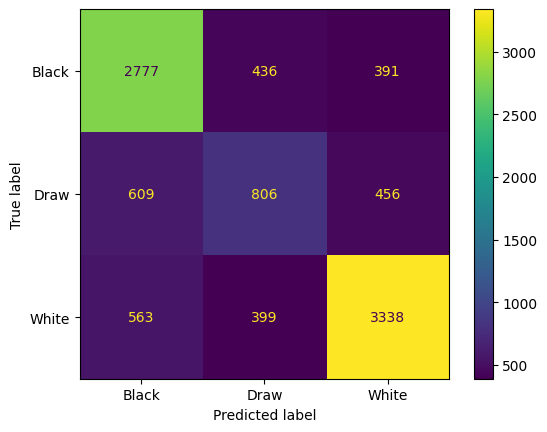

In [19]:
accuracy = accuracy_score(y_test, prediction)
print(accuracy*100)

ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test)

In [20]:
chess_data_corr = chess_data.corr(numeric_only=True)
chess_data_corr

,White Elo,Black Elo,White RD,Black RD,PlyCount
White Elo,1.000000,0.299472,0.115327,0.067678,0.119448
Black Elo,0.299472,1.000000,0.070539,0.117887,0.175663
White RD,0.115327,0.070539,1.000000,0.227320,-0.037251
Black RD,0.067678,0.117887,0.227320,1.000000,-0.025626
PlyCount,0.119448,0.175663,-0.037251,-0.025626,1.000000


([<matplotlib.axis.YTick at 0x1a2d093efd0>,
 [Text(0, 0, 'White Elo'),
  Text(0, 1, 'Black Elo'),
  Text(0, 2, 'White RD'),
  Text(0, 3, 'Black RD'),
  Text(0, 4, 'PlyCount')])

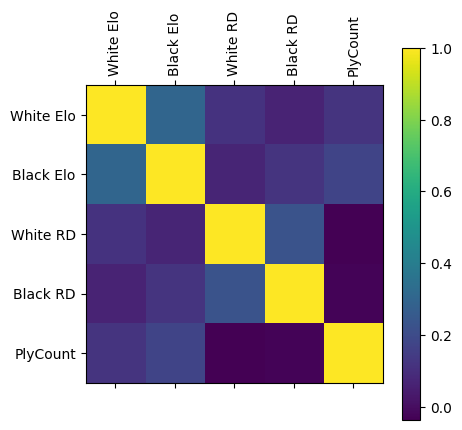

In [21]:
plt.matshow(chess_data_corr)
plt.colorbar()
plt.xticks(range(len(chess_data_corr.index)), chess_data_corr.index, rotation=90)
plt.yticks(range(len(chess_data_corr.index)), chess_data_corr.index)

Text(0, 0.5, 'Percent Accuracy')

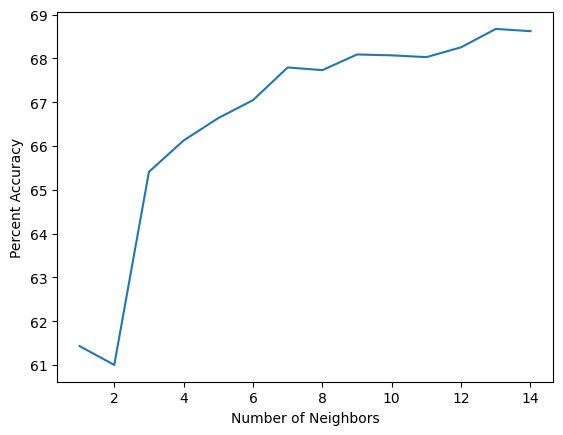

In [23]:
X = chess_data[["White Elo", "Black Elo"]]
y = chess_data["Result-Winner"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

k_value = []
accuracies = []

for k in range(1, 15, 1):
    classifier = KNeighborsClassifier(n_neighbors=k)
    classifier.fit(X_train, y_train)
    predictions = classifier.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    k_value.append(k)
    accuracies.append(accuracy*100)

plt.plot(k_value, accuracies)
plt.xlabel("Number of Neighbors")
plt.ylabel("Percent Accuracy")

68.25575447570333


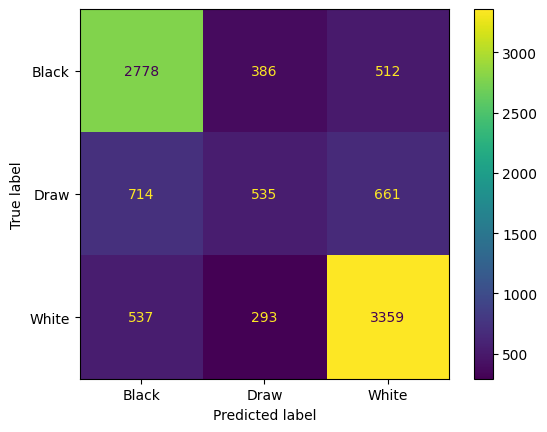

In [25]:
classifier = KNeighborsClassifier(n_neighbors=12)
classifier.fit(X_train, y_train)
predictions = classifier.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(accuracy*100)
ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test)

In [26]:
chess_data.columns

Index(['Game', 'White', 'Black', 'White Elo', 'Black Elo', 'White RD',
       'Black RD', 'WhiteIsComp', 'BlackIsComp', 'TimeControl', 'Date', 'Time',
       'White Clock', 'Black Clock', 'ECO', 'PlyCount', 'Result',
       'Result-Winner', 'Commentaries', 'Moves'],
      dtype='object')

In [27]:
chess_data.info

<bound method DataFrame.info of                                Game       White       Black  White Elo  \
0         "zerowin" vs "GeidiPrime"     zerowin  GeidiPrime       2848   
1         "GeidiPrime" vs "SlowBox"  GeidiPrime     SlowBox       2455   
2         "zerowin" vs "GeidiPrime"     zerowin  GeidiPrime       2846   
3         "GeidiPrime" vs "zerowin"  GeidiPrime     zerowin       2459   
4        "FishTest" vs "GeidiPrime"    FishTest  GeidiPrime       3033   
...                             ...         ...         ...        ...   
48866         "Hutnik" vs "zerowin"      Hutnik     zerowin       2888   
48867   "GeidiPrime" vs "GnuCheese"  GeidiPrime   GnuCheese       2473   
48868         "zerowin" vs "Hutnik"     zerowin      Hutnik       2594   
48869         "Hutnik" vs "zerowin"      Hutnik     zerowin       2893   
48870         "zerowin" vs "Hutnik"     zerowin      Hutnik       2591   

       Black Elo  White RD  Black RD WhiteIsComp BlackIsComp TimeControl  \
0  

In [31]:
chess_data_cols = chess_data[["ECO","PlyCount", "Result-Winner"]].dropna() 

In [32]:
chess_data_cols["ECO"] = pd.Categorical(chess_data_cols["ECO"]
chess_data_cols["ECO_Codes"] = chess_data_cols["ECO"].cat.codes

titanic_test_cols["Embarked"] = pd.Categorical(titanic_test_cols["Embarked"])
titanic_test_cols["Embarked_Codes"] = titanic_test_cols["Embarked"].cat.codes

,ECO,PlyCount,Result-Winner
0,A30,72,Draw
1,D01,127,White
2,A40,77,White
3,C11,128,Black
4,C07,131,White
...,...,...,...
48866,C96,109,White
48867,D01,237,White
48868,D45,93,Draw
48869,C96,147,White


In [33]:
X_train = chess_data_cols[["PlyCount", "ECO"]]
y_train = chess_data_cols["Result-Winner"]

X_test = chess_data_cols[["PlyCount", "ECO"]]
y_test = chess_data_cols["Result-Winner"]

classifier = KNeighborsClassifier(n_neighbors=20)
classifier.fit(X_train, y_train)
predictions = classifier.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print(accuracy*100)

ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test)

ValueError: could not convert string to float: 'A30'